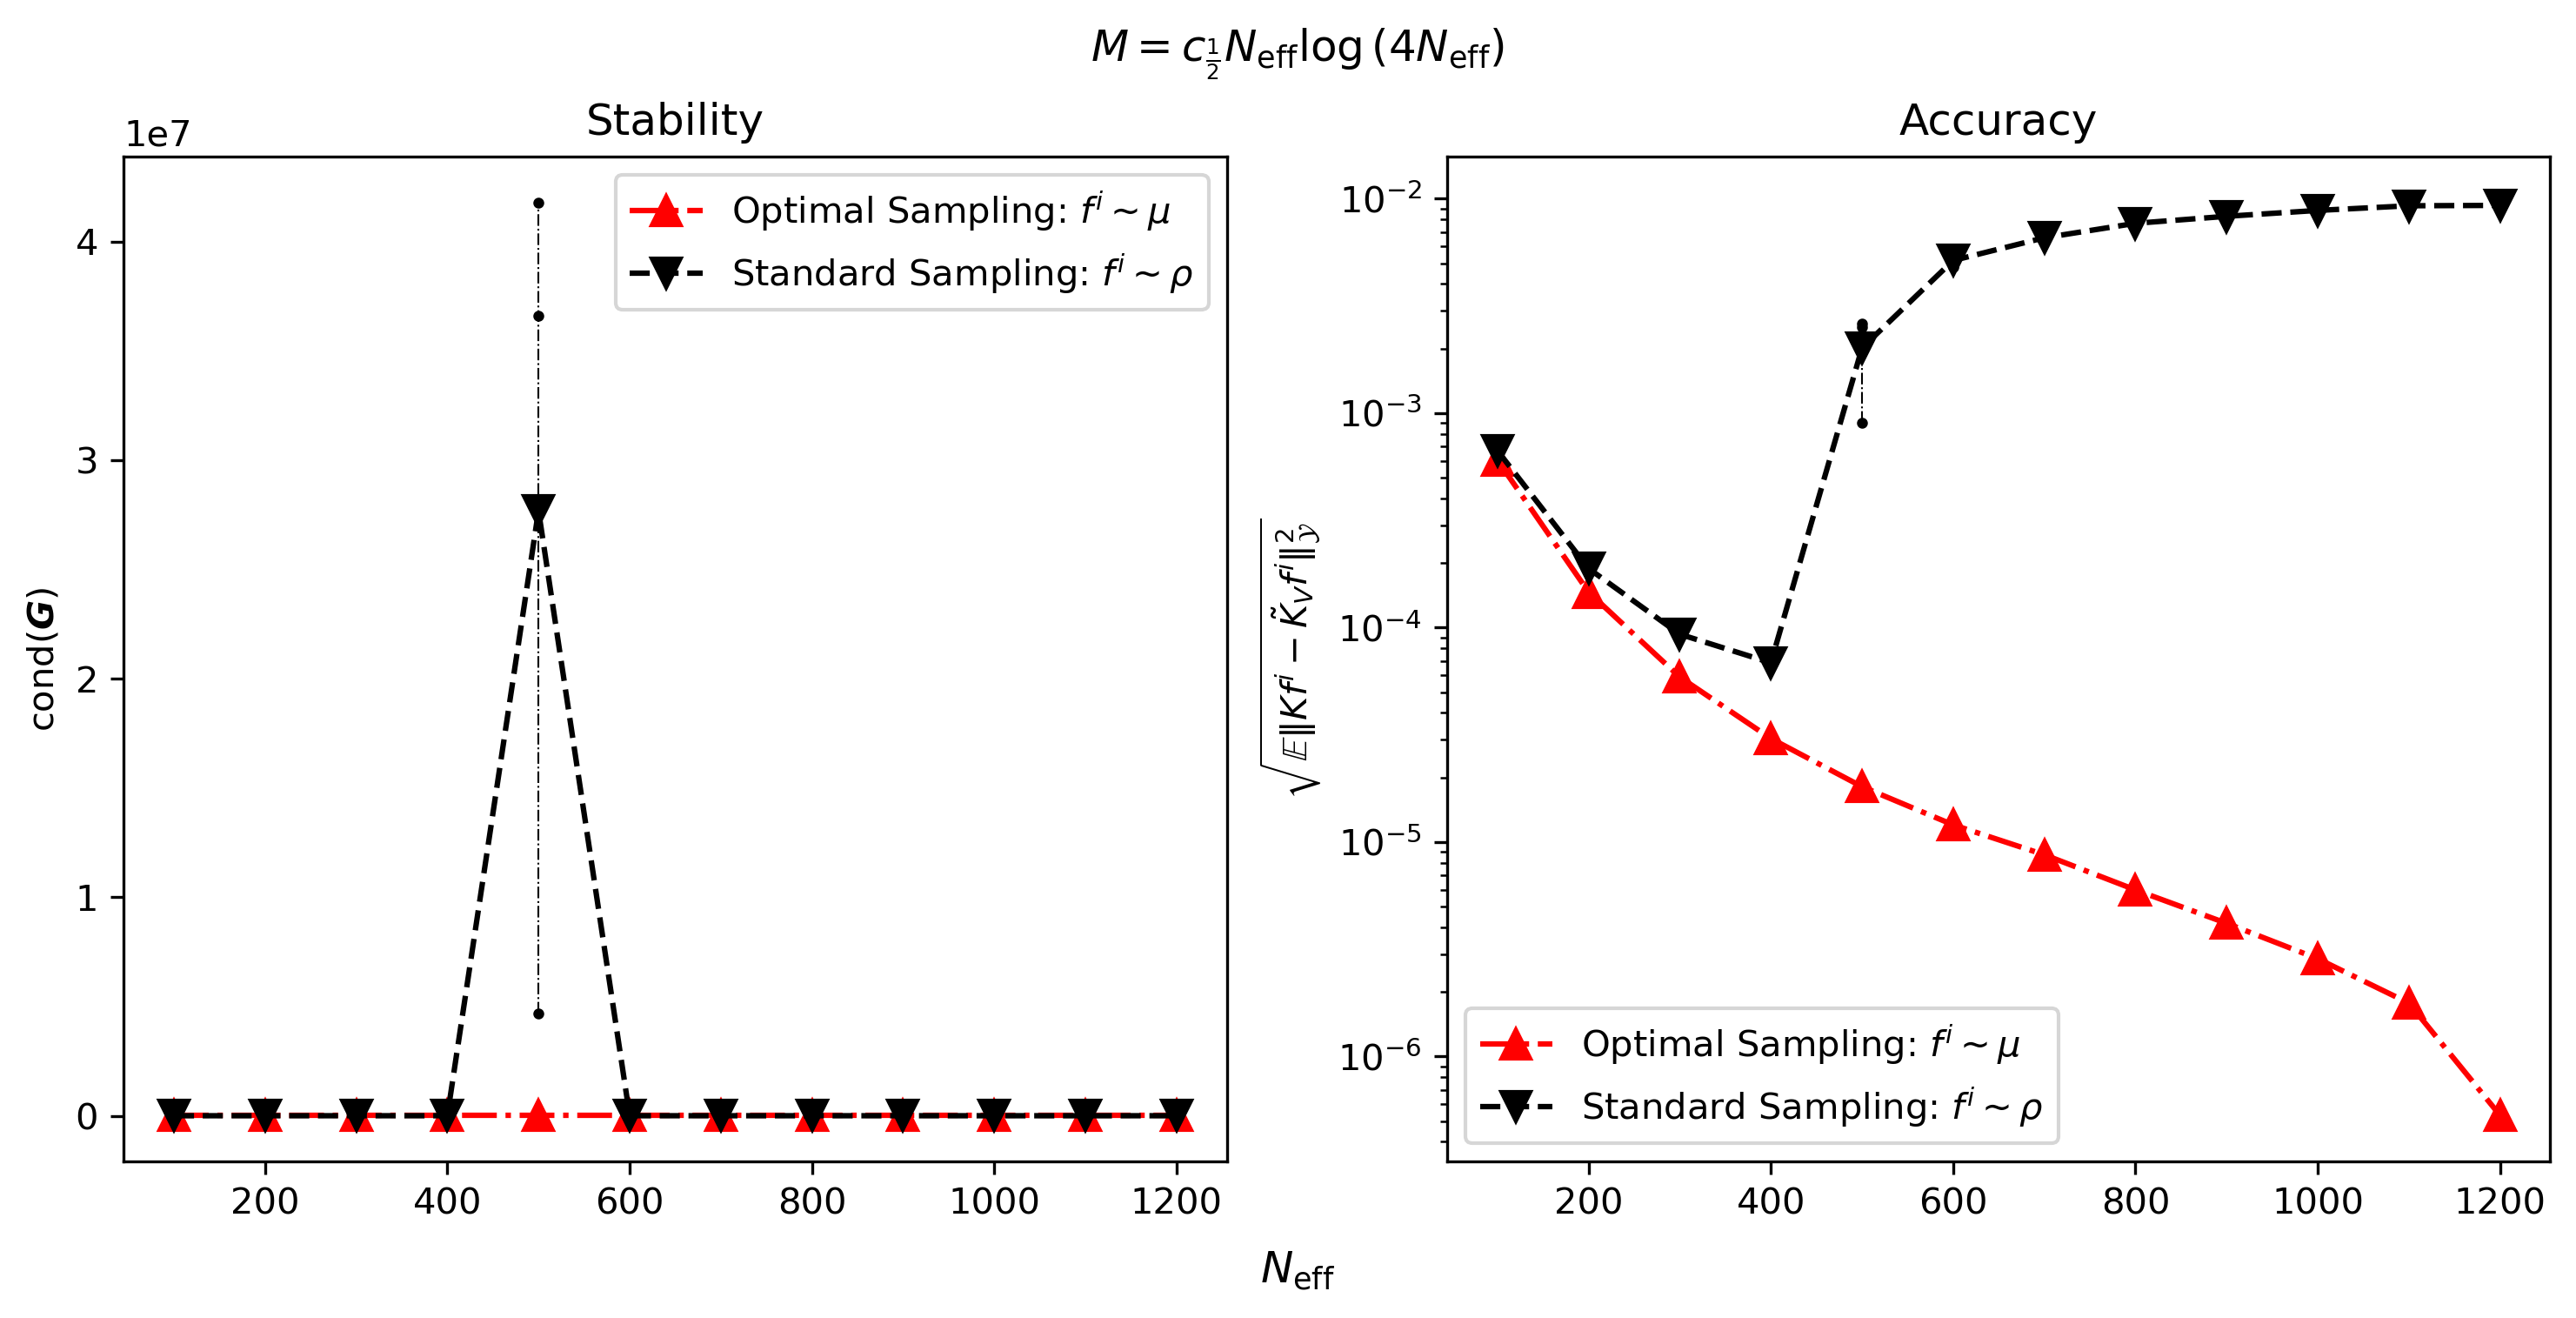

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import sys
sys.path.insert(0,"../Modules/")
from Block_WLS import Block_WLS
from index_set import index_set
from Tensor_InducedSamp import Jacobi_Tensor_Induced_Sampling
from jacobi_sampling import jacobi_tensor_samp

def err_cond(n,Induced):
 
    max_univariate_mode = 35
    i = np.arange(1, max_univariate_mode + 1).reshape(-1, 1) 
    j = np.arange(1, max_univariate_mode + 1).reshape(1, -1)  
    modes = (i+j).flatten()
    jacobi_params = [ [(modes[k]**(3)),(modes[k]**(3))] for k in range(modes.shape[0])]


    hc_param = 1
    idx_set =  np.zeros((n,modes.shape[0]))
    idx_set[:n,:n] = np.eye(n)

    N = idx_set.shape[0]    
    M = int(6.5*N * np.log(4*N)) 
    M_test = 500            

    evals = -1/ (np.pi**2 * (i**2 + j**2))
    operator_diag = evals.flatten()

    def sample_input(M, idx_set, induced = True):
        """ 
        Sample train and test forcing function spectral coeffs via Induced and MC sampling, resp.
        """
        if induced == True: 
            return Jacobi_Tensor_Induced_Sampling(M,idx_set,jacobi_params, max_poly_degree=hc_param)
        else: 
            return jacobi_tensor_samp(jacobi_params ,M_test)

    def apply_operator(f):
        return f * operator_diag

    input_samples = sample_input(M=M, idx_set=idx_set, induced=Induced)
    test_input_samples = sample_input(M = M, idx_set= idx_set, induced=False)
    output_samples = apply_operator(input_samples)
    test_output_samples = apply_operator(test_input_samples)

    wls_operator = Block_WLS(jacobi_params, idx_set, input_samples, output_samples, induced = Induced)

    test_approx_outputs = wls_operator.apply(test_input_samples)
    test_errors = np.linalg.norm(test_approx_outputs - test_output_samples, axis = 1)**2

    return np.sqrt(np.mean(test_errors)), (np.linalg.cond(wls_operator.A))**2


runs = 3
Dims = np.arange(100,1300,100)
C_Ind = np.zeros((Dims.shape[0], runs))
C_Std = np.zeros((Dims.shape[0], runs))
E_Ind = np.zeros((Dims.shape[0], runs))
E_Std = np.zeros((Dims.shape[0], runs))
for d in range(Dims.shape[0]):
    for r in range(runs):
        E_Ind[d,r],C_Ind[d,r] = err_cond(Dims[d], True)
        E_Std[d,r], C_Std[d,r] = err_cond(Dims[d], False)

np.save('Data/Condition_Ind.npy', C_Ind)
np.save('Data/Condition_Std.npy', C_Std)
np.save('Data/Err_Ind.npy', E_Ind)
np.save('Data/Err_Std.npy', E_Std)

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
fig,ax = plt.subplots(ncols = 2, figsize = (12,5), sharex = True)
for i in range(len(Dims)):
    ax[0].plot(np.ones(runs)*Dims[i], C_Ind[i,:], 'ro', markersize = 2)
    ax[0].plot(np.ones(100)*Dims[i], np.linspace(C_Ind[i].min(), C_Ind[i].max(),100), 'r-.', linewidth = 0.5)
    ax[0].plot(np.ones(runs)*Dims[i], C_Std[i,:], 'ko', markersize = 2)
    ax[0].plot(np.ones(100)*Dims[i], np.linspace(C_Std[i].min(), C_Std[i].max(),100), 'k-.', linewidth = 0.5)

    ax[1].plot(np.ones(runs)*Dims[i], E_Ind[i,:], 'ro', markersize = 2)
    ax[1].plot(np.ones(100)*Dims[i], np.linspace(E_Ind[i].min(), E_Ind[i].max(),100), 'r-.', linewidth = 0.5)
    ax[1].plot(np.ones(runs)*Dims[i], E_Std[i,:], 'ko', markersize = 2)
    ax[1].plot(np.ones(100)*Dims[i], np.linspace(E_Std[i].min(), E_Std[i].max(),100), 'k-.', linewidth = 0.5)

ax[0].plot(Dims,np.mean(C_Ind, axis = 1), "r^-.", markersize = 8, label = r'Optimal Sampling: $f^i\sim \mu$')
ax[0].plot(Dims,np.mean(C_Std, axis = 1), "kv--", markersize = 8, label = r"Standard Sampling: $f^i\sim \rho$")

ax[1].plot(Dims,np.mean(E_Ind, axis = 1), "r^-.", markersize = 8, label = r'Optimal Sampling: $f^i\sim \mu$')
ax[1].plot(Dims,np.mean(E_Std, axis = 1), "kv--", markersize = 8, label = r"Standard Sampling: $f^i\sim \rho$")

ax[0].set(ylabel = r"$\mathrm{cond}(\boldsymbol{G})$", title = "Stability")
ax[1].set(ylabel = r"$\sqrt{\mathbb{E}\Vert Kf^i - \tilde{K}_V f^i \Vert_{\mathcal{Y}}^2}$", yscale = 'log', title = "Accuracy")

ax[0].legend(loc = 'best')
ax[1].legend(loc = 'best')

fig.supxlabel(r"$N_{\mathrm{eff}}$")
fig.suptitle(r"$M = c_{\frac{1}{2}} N_{\mathrm{eff}} \log\left(4N_{\mathrm{eff}}\right)$")
plt.savefig("Plots/cond_err.png",bbox_inches = 'tight')
plt.show()


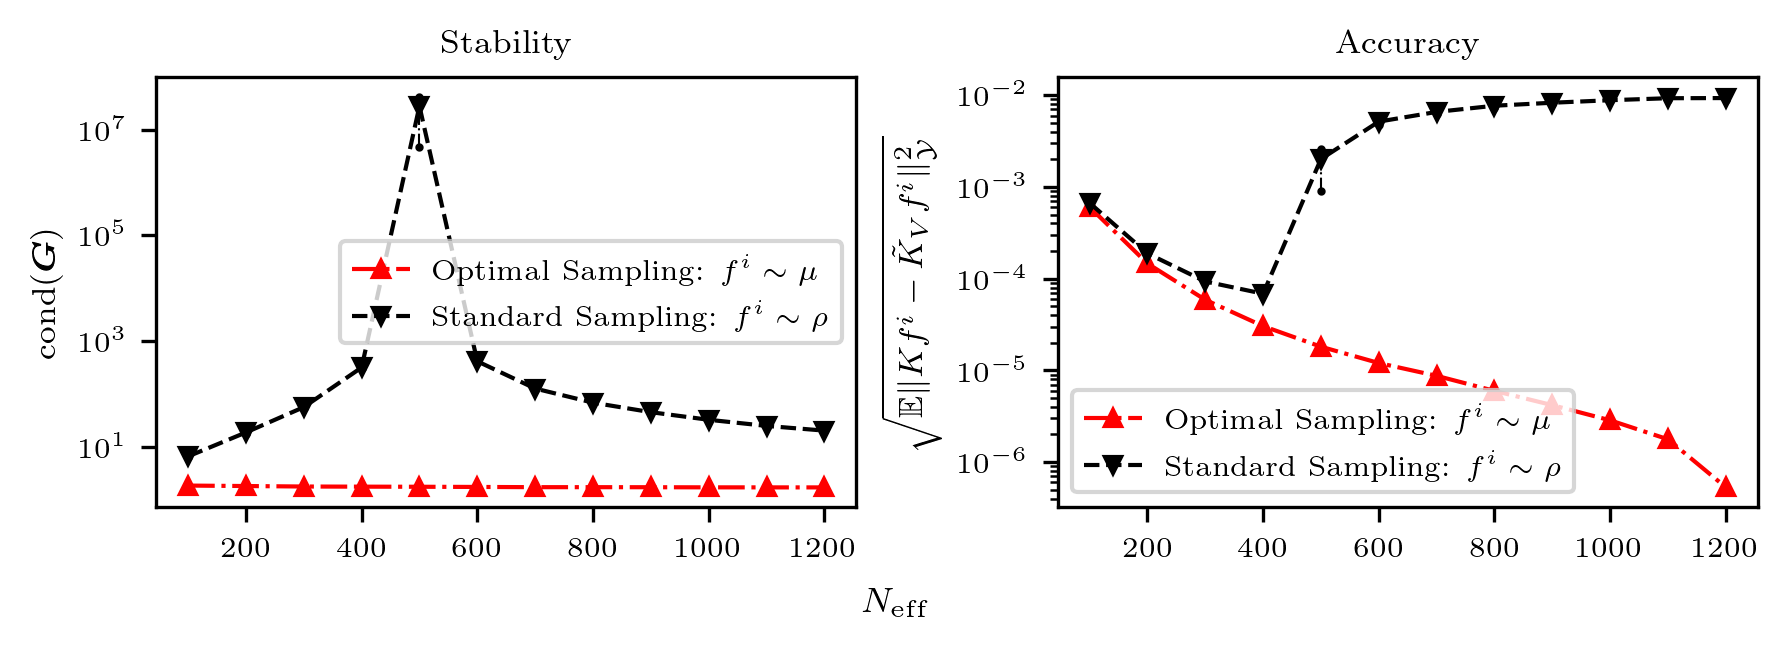

In [2]:
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
# General params 
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "Computer Modern"
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams['savefig.transparent'] = True
plt.rcParams["savefig.format"] = "pdf"
mpl.rcParams['figure.dpi'] = 300

mpl.rcParams["pdf.fonttype"] = 42   # TrueType
mpl.rcParams["ps.fonttype"] = 42

# Set figure sizes 
textwidth_pt = 422.52252                     
pt_to_inch = 1.0 / 72.27
subfig_ratio = 1.0
fig_width = textwidth_pt * pt_to_inch  *subfig_ratio         
fig_height = fig_width * 0.35                     
# Font sizes
base = 7  # match LaTeX \normalsize
plt.rcParams["font.size"] = base
plt.rcParams["axes.labelsize"] = base + 1      
plt.rcParams["axes.titlesize"] = base + 1      
plt.rcParams["xtick.labelsize"] = base         
plt.rcParams["ytick.labelsize"] = base         
plt.rcParams["legend.fontsize"] = base         
# Markersizes
markersize_small = 1
linewidth_small = 0.5
markersize_large = 4
linewidth_large = 1 


runs = 3
Dims = np.arange(100,1300,100)

C_Ind = np.load('Data/Condition_Ind.npy')
C_Std = np.load('Data/Condition_Std.npy')
E_Ind = np.load('Data/Err_Ind.npy')
E_Std = np.load('Data/Err_Std.npy')

fig,ax = plt.subplots(ncols = 2, figsize = (fig_width,fig_height), sharex = True, layout = 'constrained')
for i in range(len(Dims)):
    ax[0].plot(np.ones(runs)*Dims[i], C_Ind[i,:], 'ro', markersize = markersize_small)
    ax[0].plot(np.ones(100)*Dims[i], np.linspace(C_Ind[i].min(), C_Ind[i].max(),100), 'r-.', linewidth = linewidth_small)
    ax[0].plot(np.ones(runs)*Dims[i], C_Std[i,:], 'ko', markersize = markersize_small)
    ax[0].plot(np.ones(100)*Dims[i], np.linspace(C_Std[i].min(), C_Std[i].max(),100), 'k-.', linewidth = linewidth_small)

    ax[1].plot(np.ones(runs)*Dims[i], E_Ind[i,:], 'ro', markersize = markersize_small)
    ax[1].plot(np.ones(100)*Dims[i], np.linspace(E_Ind[i].min(), E_Ind[i].max(),100), 'r-.', linewidth = linewidth_small)
    ax[1].plot(np.ones(runs)*Dims[i], E_Std[i,:], 'ko', markersize = markersize_small )
    ax[1].plot(np.ones(100)*Dims[i], np.linspace(E_Std[i].min(), E_Std[i].max(),100), 'k-.', linewidth = linewidth_small)

ax[0].plot(Dims,np.mean(C_Ind, axis = 1), "r^-.", markersize = markersize_large,linewidth = linewidth_large, label = r'Optimal Sampling: $f^i\sim \mu$')
ax[0].plot(Dims,np.mean(C_Std, axis = 1), "kv--", markersize = markersize_large, linewidth = linewidth_large, label = r"Standard Sampling: $f^i\sim \rho$")

ax[1].plot(Dims,np.mean(E_Ind, axis = 1), "r^-.", markersize = markersize_large, linewidth = linewidth_large, label = r'Optimal Sampling: $f^i\sim \mu$')
ax[1].plot(Dims,np.mean(E_Std, axis = 1), "kv--", markersize = markersize_large, linewidth = linewidth_large, label = r"Standard Sampling: $f^i\sim \rho$")


ax[0].set(ylabel = r"$\mathrm{cond}(\boldsymbol{G})$",title = "Stability", yscale = 'log')
ax[1].set(ylabel = r"$\sqrt{\mathbb{E}\Vert Kf^i - \tilde{K}_V f^i \Vert_{\mathcal{Y}}^2}$", yscale = 'log', title = "Accuracy")

ax[0].legend(loc = 'best')
ax[1].legend(loc = 'best')

fig.supxlabel(r"$N_{\mathrm{eff}}$")
#fig.suptitle(r"$M = c_{\frac{1}{2}} N_{\mathrm{eff}} \log\left(4N_{\mathrm{eff}}\right)$")
plt.savefig("Plots/cond_err.pdf",bbox_inches = 'tight')
plt.show()